# End-to-End decoding by EEGSPDNet
This notebook uses EEGSPDNet (Wilson et al., 2024) to perform End-to-End decoding of visual semantic stimuli of EEG signals.<br>
It uses a SPDNet preceded by region (or channel, as usually refered in the literature) convolutional layers.

I will use the spd_learn library as first to access the potential of each method.<br>
I could - and maybe I will - implement this on my own if this is a godd approach.

In [4]:
# Lib
import sys
sys.path.append("/home/rffl/files/ic/utils/")

import torch
import datagen, eegdataset #type: ignore
from spd_learn.models import EEGSPDNet
from torch.utils.data import DataLoader
from torchmetrics.classification import ConfusionMatrix
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
device

AttributeError: module 'numpy' has no attribute 'ndarray'

### Data

In [4]:
# Data config
classVec = [i+1 for i in range(10)]
subVec = [i+1 for i in range(10)]

nClass = len(classVec)
nSub = len(subVec)

In [31]:
# Data gen
train_path, test_path = datagen.generatedataset(classVec, subVec, 0.75, False)

Saved ./train.npy shape = (6000, 17, 100)
Saved ./test.npy shape = (2000, 17, 100)


In [32]:
# xDAWN treatment
import pyriemann as rmn
xDAWNfilters = 5
estimator = "lwf"

X_train = np.load(train_path, allow_pickle=True)
X_test = np.load(test_path, allow_pickle=True)

y_train = np.array([])
part = len(X_train) // len(classVec)
for i in range(len(classVec)):
    y_train = np.concatenate([y_train, i * np.ones(part)])

xdawn = rmn.estimation.Xdawn(nfilter=xDAWNfilters, estimator=estimator)
xdawn.fit(X_train, y_train)

X_train = np.einsum('fc,nct->nft', xdawn.filters_, X_train)
X_test  = np.einsum('fc,nct->nft', xdawn.filters_, X_test)

np.save(train_path, X_train )
np.save(test_path, X_test )

In [5]:
# Dataset and Dataloader init
trainDataset = eegdataset.KClassDataset(nClass, "./train.npy")
trainLoader = DataLoader(trainDataset, 40, True, num_workers=4)

testDataset = eegdataset.KClassDataset(nClass, "./test.npy")
testLoader = DataLoader(testDataset, 40, True, num_workers=4)

### Utilitary functions

In [6]:
import time
def regular_train(model, classVec, trainLoader, testLoader, epochs, device):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_hist_loss = []
    test_hist_loss = []

    train_hist_acc = []
    test_hist_acc = []

    begin = time.time()
    print(f"Begin {begin}")
    for epoch in range(epochs):
        train_loss, train_acc = train(model, trainLoader, criterion, optimizer, device)
        test_loss, test_acc = test(model, testLoader, criterion, device)
        train_hist_loss.append(train_loss); train_hist_acc.append(train_acc)
        test_hist_loss.append(test_loss); test_hist_acc.append(test_acc)
        print(f"Epoch {epoch+1}: "
        f"Train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"Test loss {test_loss:.4f}, acc {test_acc:.4f} | "
        f"Time {time.time() - begin} s")

    confmat = ConfusionMatrix(task="multiclass", num_classes=len(classVec))    

    fig, axs = plt.subplots(1,2)
    axs[0].plot(range(epochs), train_hist_loss, label="Train Loss")
    axs[0].plot(range(epochs), test_hist_loss, label="Test Loss")
    axs[0].legend()

    axs[1].plot(range(epochs), train_hist_acc, label="Train Accuracy")
    axs[1].plot(range(epochs), test_hist_acc, label="Test Accuracy")
    axs[1].legend()
    fig.show()

    for X, y in testLoader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        preds = torch.argmax(logits, dim=1)

        confmat.update(preds.cpu(), y.cpu())

    confmatrix = confmat.compute()
    plot_confusion_matrix(confmatrix, classVec)

def train(model, trainLoader, criterion, optimizer, device):
    torch.cuda.empty_cache()
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X, y in trainLoader:
        X = X.to(device); y = y.to(device)

        optimizer.zero_grad()
        y_hat = model(X)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = y_hat.argmax(dim=1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    
    avg_loss = total_loss / len(trainLoader)
    acc = correct / total
    return avg_loss, acc

@torch.no_grad()
def test(model, testLoader, criterion, device):
    torch.cuda.empty_cache()
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    for X, y in testLoader:
        X = X.to(device); y = y.to(device)

        y_hat = model(X)
        total_loss += criterion(y_hat, y).item()

        pred = y_hat.argmax(dim=1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    
    avg_loss = total_loss / len(testLoader)
    acc = correct / total
    return avg_loss, acc

def plot_confusion_matrix(confmatrix, class_names=None):
    plt.figure(figsize=(6, 5))
    plt.imshow(confmatrix, interpolation='nearest')
    plt.title("Confusion Matrix")
    plt.colorbar()

    num_classes = confmatrix.shape[0]

    # Tick labels
    if not class_names:
        class_names = [str(i) for i in range(num_classes)]

    plt.xticks(range(num_classes), class_names, rotation=45)
    plt.yticks(range(num_classes), class_names)

    # Print values inside cells
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, str(confmatrix[i, j].item()),
                     ha="center", va="center", color="white" if confmatrix[i, j] > confmatrix.max()/2 else "black")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

### Adaptative LWF shrinkage addition

In [1]:
from spd_learn.modules import Shrinkage

class EEGSPDNetLWF(EEGSPDNet):
    def __init__(self, *args, initShrinkage=0.0, **kwargs):
        super().__init__(*args, **kwargs)
        n_cov = self.n_chans * self.n_filters
        self.shrinkage = Shrinkage(n_chans=n_cov, init_shrinkage=initShrinkage, learnable=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.cov_pool(x)
        x = self.shrinkage(x)
        x = self.spdnet(x)
        x = self.dropout(x)
        x = self.linear(x)
        return x

AttributeError: module 'numpy' has no attribute 'ndarray'

### Train

In [9]:
device = torch.device("cuda:1")
model = EEGSPDNet(50, 10, n_filters=10, bimap_sizes=(2, 3), filter_time_length = 50, final_layer_drop_prob=0.25, spd_drop_prob=0.25).to(device)
regular_train(model, classVec, trainLoader, testLoader, 75, device)

Begin 1780584820.2880073


Epoch 1: Train loss 2.3858, acc 0.1010 | Test loss 2.3022, acc 0.1340 | Time 93.98246836662292 s
Epoch 2: Train loss 2.3728, acc 0.0998 | Test loss 2.3080, acc 0.1445 | Time 188.35389804840088 s
Epoch 3: Train loss 2.3698, acc 0.1068 | Test loss 2.3652, acc 0.1285 | Time 282.89842104911804 s
Epoch 4: Train loss 2.3773, acc 0.1037 | Test loss 2.3793, acc 0.1225 | Time 377.4912223815918 s
Epoch 5: Train loss 2.3780, acc 0.1028 | Test loss 2.3407, acc 0.1380 | Time 471.93552112579346 s


KeyboardInterrupt: 

Begin 1780522308.0837898
Epoch 1: Train loss 2.4629, acc 0.1192 | Test loss 2.1563, acc 0.2050 | Time 101.51503467559814 s
Epoch 2: Train loss 2.3432, acc 0.1597 | Test loss 2.0293, acc 0.2785 | Time 204.11904668807983 s
Epoch 3: Train loss 2.2329, acc 0.2090 | Test loss 2.1660, acc 0.2705 | Time 307.16148042678833 s
Epoch 4: Train loss 2.1949, acc 0.2223 | Test loss 2.0743, acc 0.3110 | Time 410.53905415534973 s
Epoch 5: Train loss 2.1289, acc 0.2572 | Test loss 2.0649, acc 0.3165 | Time 514.1241641044617 s
Epoch 6: Train loss 2.0598, acc 0.2752 | Test loss 2.0958, acc 0.3170 | Time 617.8419053554535 s
Epoch 7: Train loss 2.0501, acc 0.2858 | Test loss 2.1368, acc 0.3350 | Time 721.60440325737 s
Epoch 8: Train loss 2.0462, acc 0.2987 | Test loss 2.1573, acc 0.3530 | Time 825.467827796936 s
Epoch 9: Train loss 1.9734, acc 0.3232 | Test loss 2.3005, acc 0.3275 | Time 929.1747481822968 s
Epoch 10: Train loss 1.9781, acc 0.3252 | Test loss 2.1779, acc 0.3520 | Time 1033.0289454460144 s
Ep

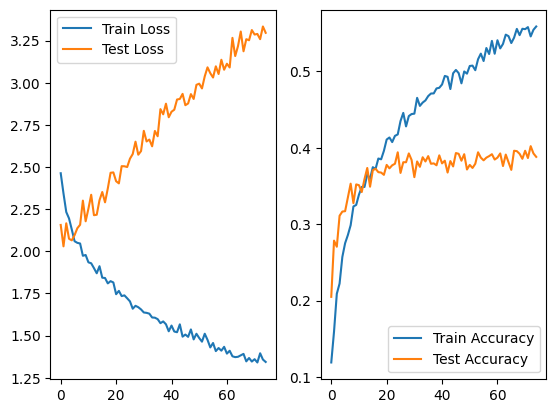

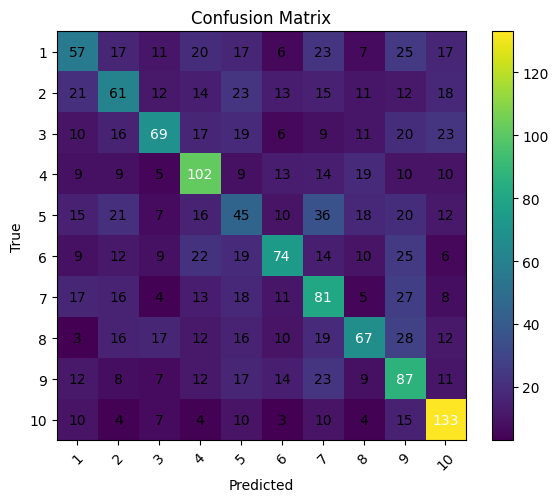

In [10]:
device = torch.device("cuda:1")
model = EEGSPDNetLWF(50, 10, n_filters=10, bimap_sizes=(2, 1), filter_time_length = 50, final_layer_drop_prob=0.5, spd_drop_prob=0.25).to(device)
regular_train(model, classVec, trainLoader, testLoader, 75, device)